In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('zimbabwe_student_dropout.csv')
df.head()

,age,gender,location,family_income,internet_access,electricity_reliability,transport_time,study_hours,attendance_rate,lms_logins,previous_grade,fees_paid,part_time_job,stress_level,dropout
0,24,Male,Urban,63.469002,Moderate,Medium,33.458884,4.489437,63.518378,7,2.1,Full,No,4.704618,0
1,21,Female,Rural,362.153776,Poor,Medium,29.252875,2.020482,84.090932,3,2.2,NaN,No,2.863387,1
2,22,Female,Urban,481.824622,Moderate,Medium,10.027318,3.345527,NaN,6,3,NaN,No,5.982555,1
3,24,Female,Rural,312.666809,Moderate,Medium,27.276996,1.507011,58.549823,3,2.1,Full,No,4.287927,0
4,20,Male,Rural,NaN,Good,High,66.109186,1.285130,60.612892,7,2.1,Full,Yes,10.000000,0


In [3]:
# ── SECTION 1: EXPLORATORY DATA ANALYSIS ──────────────────────────────────

print('Shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)

Shape: (523574, 15)

Column types:
age                          int64
gender                      object
location                    object
family_income              float64
internet_access             object
electricity_reliability     object
transport_time             float64
study_hours                float64
attendance_rate            float64
lms_logins                   int64
previous_grade              object
fees_paid                   object
part_time_job               object
stress_level               float64
dropout                      int64
dtype: object


In [4]:
df.describe()

,age,family_income,transport_time,study_hours,attendance_rate,lms_logins,stress_level,dropout
count,523574.000000,497396.000000,523574.000000,497396.000000,497396.000000,523574.000000,523574.000000,523574.000000
mean,21.000069,250.677814,45.621704,3.071724,74.715627,4.997471,5.010858,0.646562
std,1.999320,97.994334,20.417528,1.641404,14.370081,2.234502,1.950046,0.478038
min,18.000000,50.000000,5.000000,0.000000,20.000000,0.000000,1.000000,0.000000
25%,19.000000,182.535068,31.564676,1.997274,64.875701,3.000000,3.648291,0.000000
50%,21.000000,249.664059,45.202290,3.011870,74.979322,5.000000,4.996772,1.000000
75%,23.000000,317.461042,58.846161,4.040676,85.135663,6.000000,6.348826,1.000000
max,24.000000,707.891439,225.378766,24.403266,100.000000,19.000000,10.000000,1.000000


In [5]:
# check for missing values
missing = df.isnull().sum()
print(missing[missing > 0])

family_income       26178
study_hours         26178
attendance_rate     26178
fees_paid          104628
dtype: int64


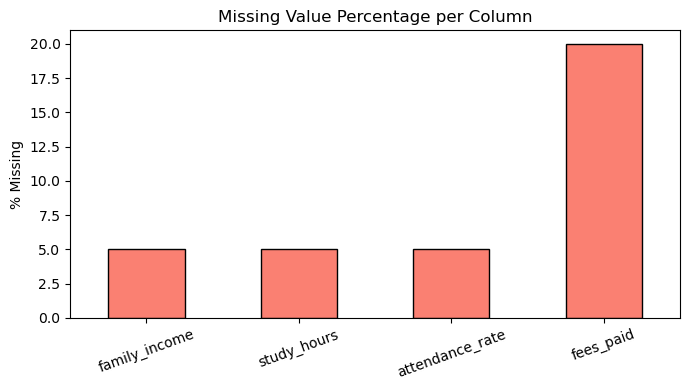

In [6]:
# visualise missing values
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(7, 4))
missing_pct.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Missing Value Percentage per Column')
plt.ylabel('% Missing')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [7]:
# dropout class balance
print(df['dropout'].value_counts())
print(df['dropout'].value_counts(normalize=True).round(3))

dropout
1    338523
0    185051
Name: count, dtype: int64
dropout
1    0.647
0    0.353
Name: proportion, dtype: float64


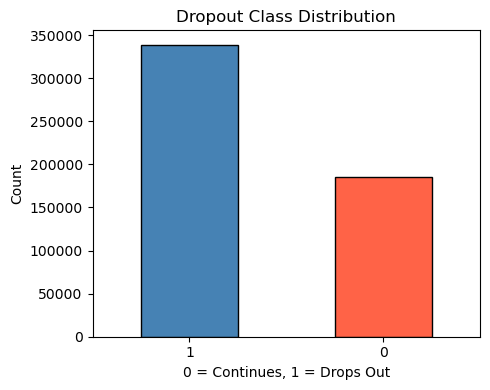

In [8]:
# class balance chart — dataset is imbalanced (64.7% dropout)
plt.figure(figsize=(5, 4))
df['dropout'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='black')
plt.title('Dropout Class Distribution')
plt.xlabel('0 = Continues, 1 = Drops Out')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

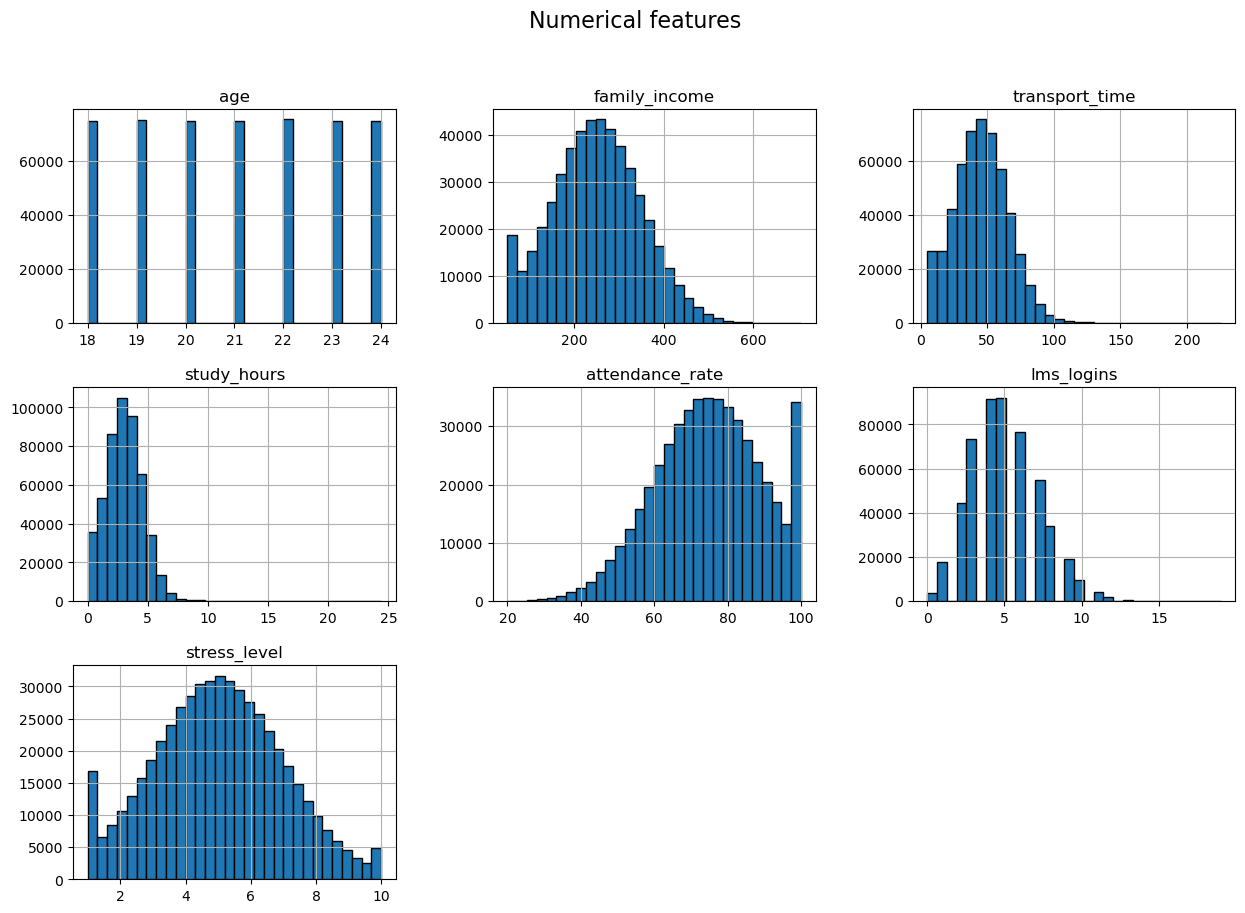

In [9]:
# numerical feature distributions
columns = ['age', 'family_income', 'transport_time', 'study_hours', 'attendance_rate', 'lms_logins', 'stress_level']
df[columns].hist(figsize=(15, 10), bins=30, edgecolor='black')
plt.suptitle('Numerical features', size=16)
plt.show()

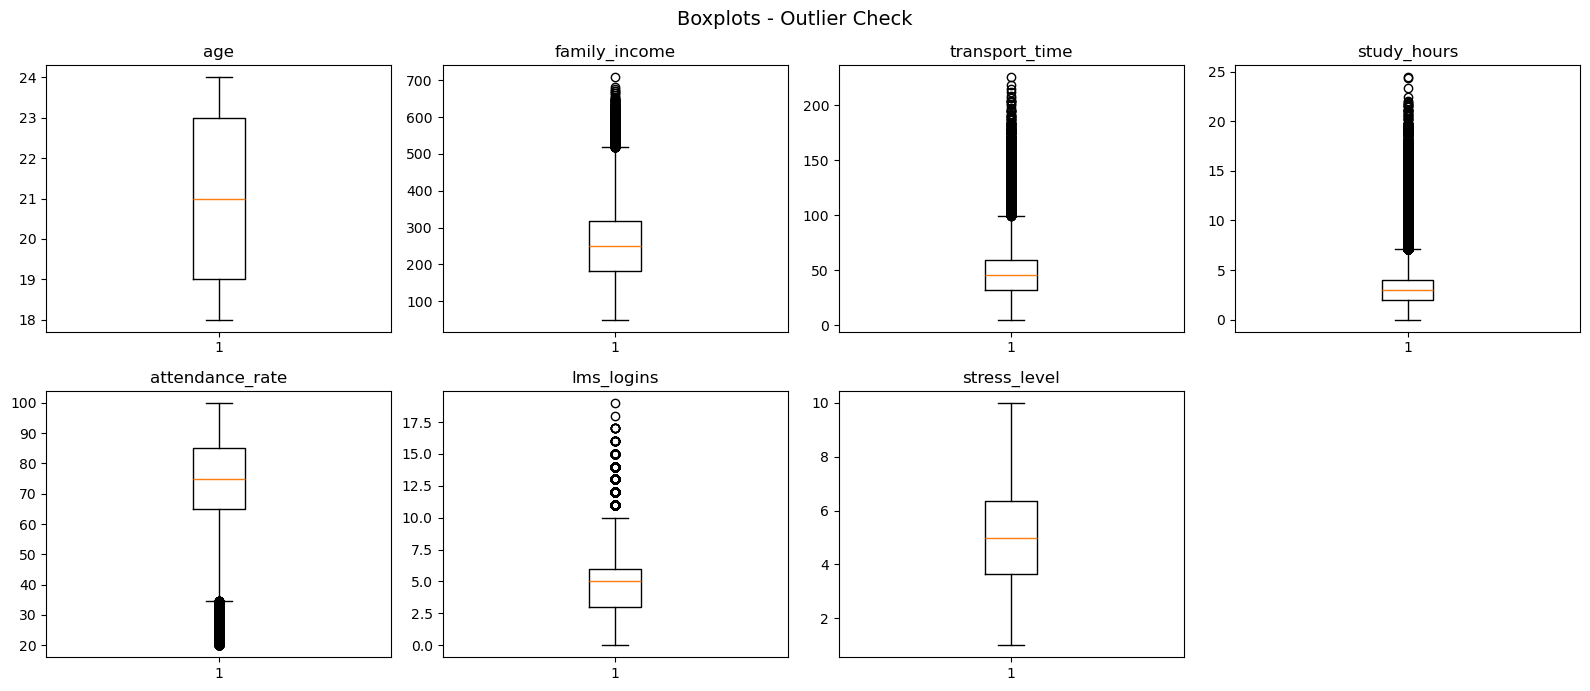

In [10]:
# outlier check using boxplots
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(columns):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.suptitle('Boxplots - Outlier Check', size=14)
plt.tight_layout()
plt.show()

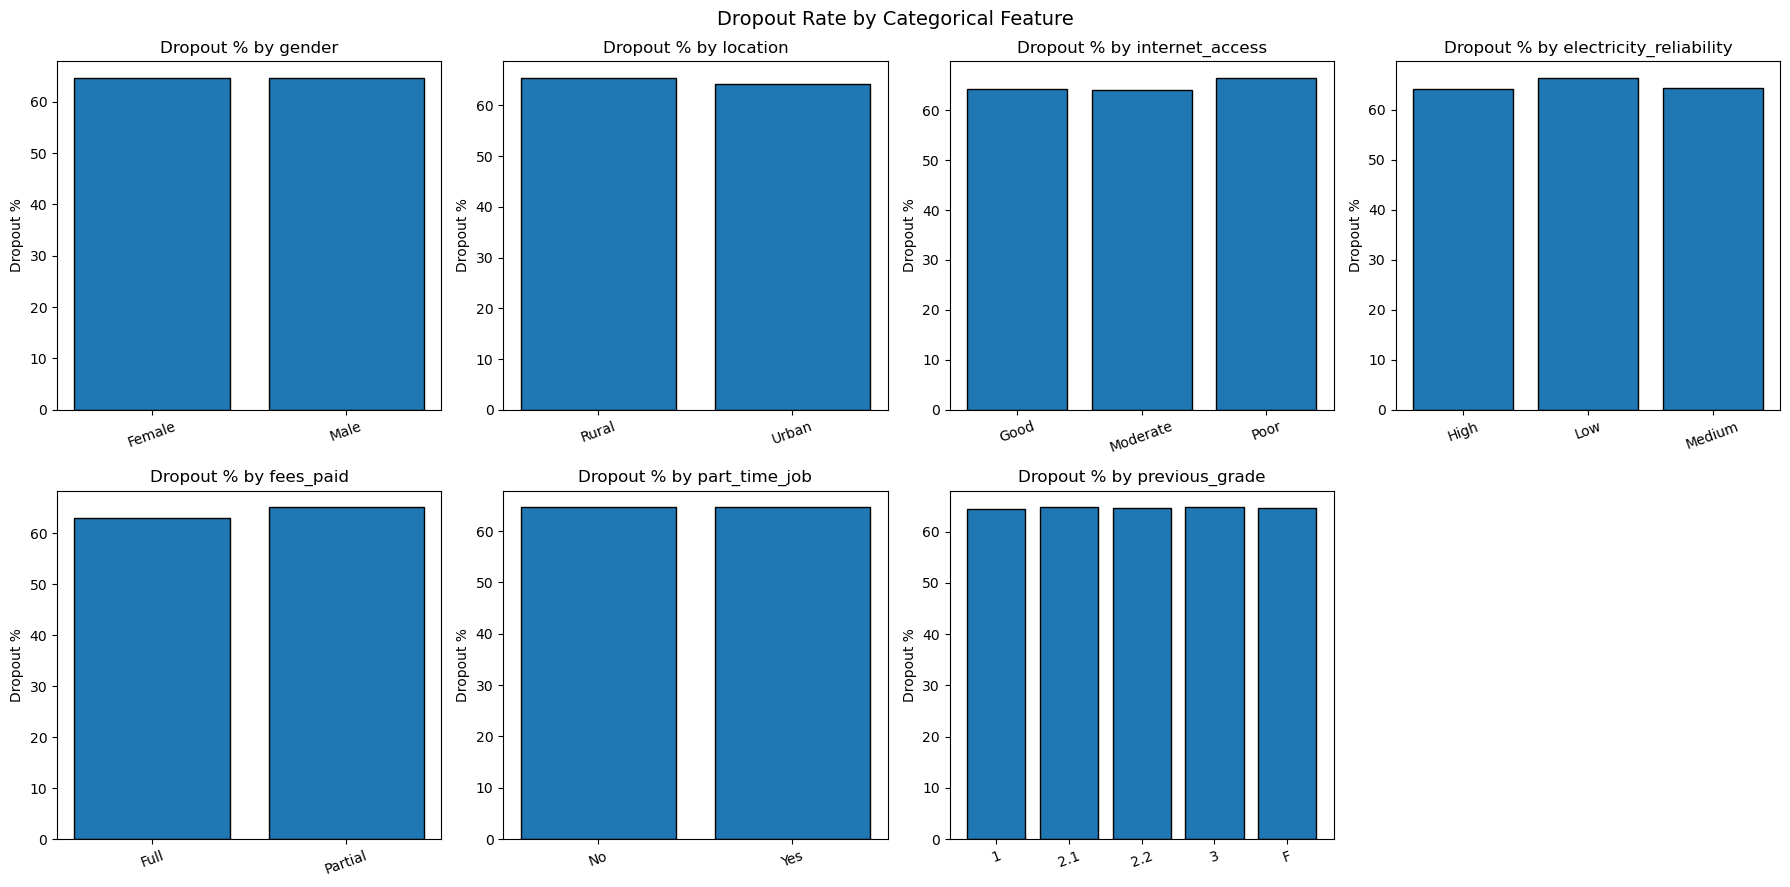

In [11]:
# categorical columns vs dropout rate
cat_cols = ['gender', 'location', 'internet_access', 'electricity_reliability', 'fees_paid', 'part_time_job', 'previous_grade']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    temp = df.groupby(col)['dropout'].mean() * 100
    axes[i].bar(temp.index, temp.values, edgecolor='black')
    axes[i].set_title(f'Dropout % by {col}')
    axes[i].set_ylabel('Dropout %')
    axes[i].tick_params(axis='x', rotation=20)
axes[-1].set_visible(False)
plt.suptitle('Dropout Rate by Categorical Feature', size=14)
plt.tight_layout()
plt.show()

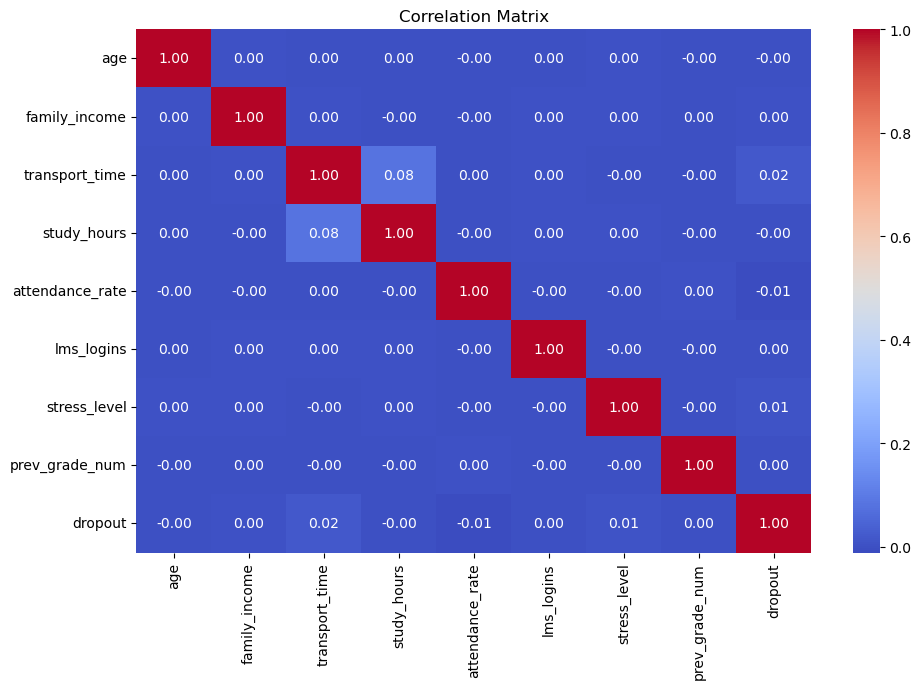

In [12]:
# correlation heatmap
grade_tmp = {'F': 0, '1': 1, '2.1': 2, '2.2': 3, '3': 4}
df_tmp = df.copy()
df_tmp['prev_grade_num'] = df_tmp['previous_grade'].map(grade_tmp)

num_for_corr = columns + ['prev_grade_num', 'dropout']
plt.figure(figsize=(10, 7))
sns.heatmap(df_tmp[num_for_corr].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [13]:
# ── SECTION 2: DATA PRE-PROCESSING ────────────────────────────────────────

# work on a copy
data = df.copy()

# fill missing fees_paid — missing likely means not paid/not recorded
data['fees_paid'] = data['fees_paid'].fillna('Unknown')

# median imputation for numeric columns
for col in ['family_income', 'study_hours', 'attendance_rate']:
    data[col] = data[col].fillna(data[col].median())

print('Missing values after cleaning:', data.isnull().sum().sum())

Missing values after cleaning: 0


In [14]:
# encode categorical columns
data['gender']        = data['gender'].map({'Male': 0, 'Female': 1})
data['location']      = data['location'].map({'Urban': 0, 'Rural': 1})
data['part_time_job'] = data['part_time_job'].map({'No': 0, 'Yes': 1})

# ordinal encoding — order matters for these
data['internet_access']         = data['internet_access'].map({'Poor': 0, 'Moderate': 1, 'Good': 2})
data['electricity_reliability'] = data['electricity_reliability'].map({'Low': 0, 'Medium': 1, 'High': 2})
data['fees_paid']               = data['fees_paid'].map({'Unknown': 0, 'Partial': 1, 'Full': 2})
data['previous_grade']          = data['previous_grade'].map({'F': 0, '1': 1, '2.1': 2, '2.2': 3, '3': 4})

print(data.dtypes)

age                          int64
gender                       int64
location                     int64
family_income              float64
internet_access              int64
electricity_reliability      int64
transport_time             float64
study_hours                float64
attendance_rate            float64
lms_logins                   int64
previous_grade               int64
fees_paid                    int64
part_time_job                int64
stress_level               float64
dropout                      int64
dtype: object


In [15]:
# scale numerical features with MinMaxScaler
scale_cols = ['age', 'family_income', 'transport_time', 'study_hours',
              'attendance_rate', 'lms_logins', 'stress_level']

scaler = MinMaxScaler()
data[scale_cols] = scaler.fit_transform(data[scale_cols])

data.head(3)

,age,gender,location,family_income,internet_access,electricity_reliability,transport_time,study_hours,attendance_rate,lms_logins,previous_grade,fees_paid,part_time_job,stress_level,dropout
0,1.000000,0,0,0.020473,1,1,0.129136,0.183969,0.543980,0.368421,2,2,0,0.411624,0
1,0.500000,1,1,0.474476,0,1,0.110051,0.082796,0.801137,0.157895,3,0,0,0.207043,1
2,0.666667,1,0,0.656377,1,1,0.022812,0.137093,0.687242,0.315789,4,0,0,0.553617,1


In [16]:
# save cleaned dataset
data.to_csv('student_dropout_cleaned.csv', index=False)
print('Cleaned dataset saved.')

Cleaned dataset saved.


In [17]:
# ── SECTION 3: FEATURE ENGINEERING ────────────────────────────────────────

# Feature 1: study_efficiency
# ratio of study hours to attendance — captures whether study time is backed by class presence
# small constant avoids division by zero
data['study_efficiency'] = data['study_hours'] / (data['attendance_rate'] + 0.01)

print('study_efficiency sample:')
print(data['study_efficiency'].describe())

study_efficiency sample:
count    523574.000000
mean          0.199483
std           0.223780
min           0.000000
25%           0.118284
50%           0.177357
75%           0.249840
max          43.680358
Name: study_efficiency, dtype: float64


In [18]:
# Feature 2: hardship_index
# composite socio-economic deprivation score
# combines low income, poor electricity and poor internet into one measure
# higher score = more disadvantaged
data['hardship_index'] = (
    (1 - data['family_income']) +
    (2 - data['electricity_reliability']) +
    (2 - data['internet_access'])
)

print('hardship_index sample:')
print(data['hardship_index'].describe())

hardship_index sample:
count    523574.000000
mean          2.395193
std           1.034754
min           0.085865
25%           1.668605
50%           2.559994
75%           2.897562
max           5.000000
Name: hardship_index, dtype: float64


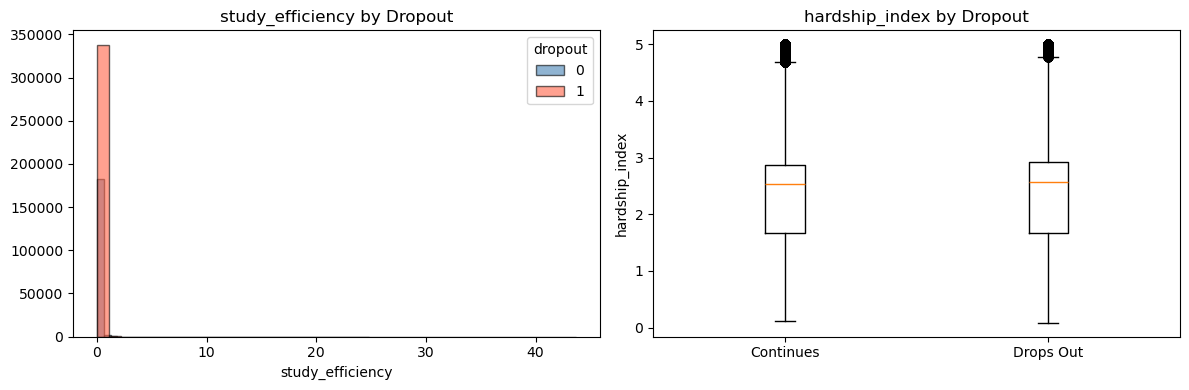

In [19]:
# check that both features separate dropout classes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for cls, color in zip([0, 1], ['steelblue', 'tomato']):
    axes[0].hist(data[data['dropout'] == cls]['study_efficiency'], bins=40,
                 alpha=0.6, color=color, label=str(cls), edgecolor='black')
axes[0].set_title('study_efficiency by Dropout')
axes[0].set_xlabel('study_efficiency')
axes[0].legend(title='dropout')

axes[1].boxplot(
    [data[data['dropout'] == 0]['hardship_index'],
     data[data['dropout'] == 1]['hardship_index']],
    labels=['Continues', 'Drops Out']
)
axes[1].set_title('hardship_index by Dropout')
axes[1].set_ylabel('hardship_index')

plt.tight_layout()
plt.show()

In [20]:
# ── SECTION 4: MODEL DEVELOPMENT ──────────────────────────────────────────

features = ['age', 'gender', 'location', 'family_income', 'internet_access',
            'electricity_reliability', 'transport_time', 'study_hours',
            'attendance_rate', 'lms_logins', 'previous_grade', 'fees_paid',
            'part_time_job', 'stress_level', 'study_efficiency', 'hardship_index']

X = data[features]
y = data['dropout']

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                     random_state=7, stratify=y)
print('Train size:', X_train.shape)
print('Test size: ', X_test.shape)

Train size: (418859, 16)
Test size:  (104715, 16)


In [21]:
# Model 1 — Decision Tree
# interpretable, handles non-linear boundaries, no scaling required
dt = DecisionTreeClassifier(max_depth=10, random_state=7)
dt.fit(X_train, y_train)
print('Decision Tree trained.')

Decision Tree trained.


In [22]:
# Model 2 — Gradient Boosting
# sequential ensemble that corrects previous errors, strong on mixed feature types
gb = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=7)
gb.fit(X_train, y_train)
print('Gradient Boosting trained.')

Gradient Boosting trained.


In [23]:
# Model 3 — Logistic Regression
# linear baseline, fast, interpretable coefficients
lr = LogisticRegression(max_iter=300, random_state=7)
lr.fit(X_train, y_train)
print('Logistic Regression trained.')

Logistic Regression trained.


In [24]:
# ── SECTION 5: MODEL EVALUATION ───────────────────────────────────────────

models = {'Decision Tree': dt, 'Gradient Boosting': gb, 'Logistic Regression': lr}
results = {}

for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1'       : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_proba), 4),
        '_pred'    : y_pred,
        '_proba'   : y_proba
    }

summary = pd.DataFrame({k: {m: v for m, v in res.items() if not m.startswith('_')}
                        for k, res in results.items()}).T
print(summary.to_string())

                     Accuracy  Precision  Recall      F1  ROC-AUC
Decision Tree          0.6444     0.6466  0.9923  0.7830   0.5251
Gradient Boosting      0.6464     0.6466  0.9995  0.7852   0.5311
Logistic Regression    0.6465     0.6466  1.0000  0.7853   0.5326


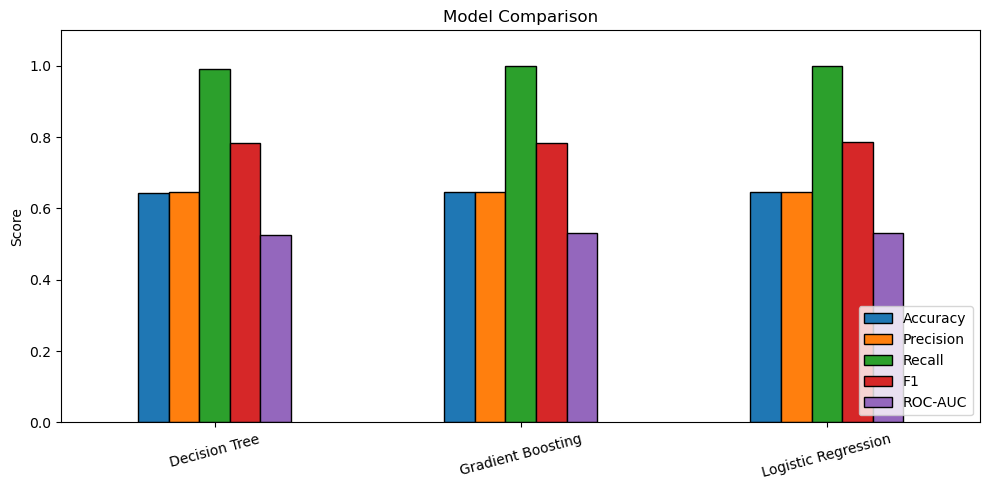

In [25]:
# bar chart comparing all metrics
summary[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(
    kind='bar', figsize=(10, 5), edgecolor='black'
)
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

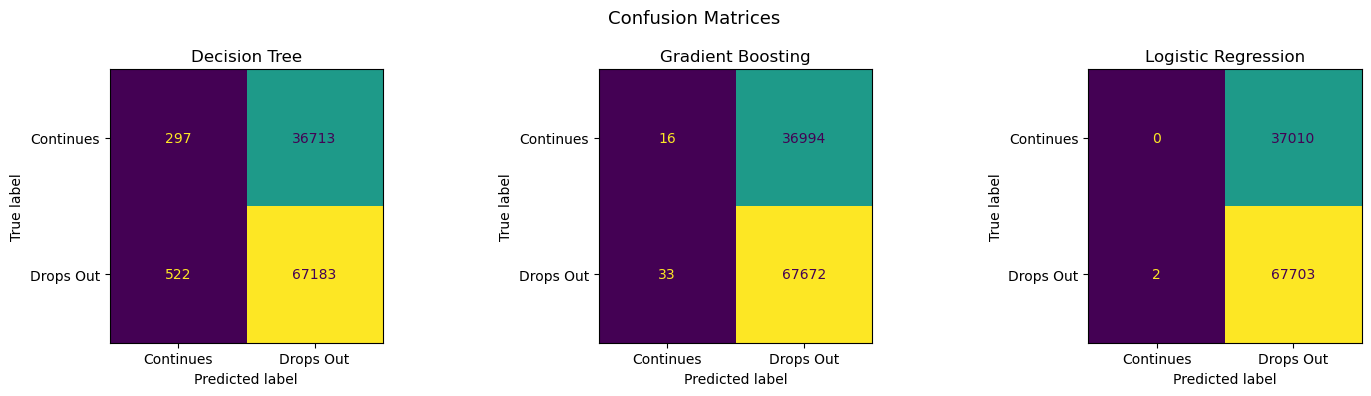

In [26]:
# confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Continues', 'Drops Out']).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.suptitle('Confusion Matrices', size=13)
plt.tight_layout()
plt.show()

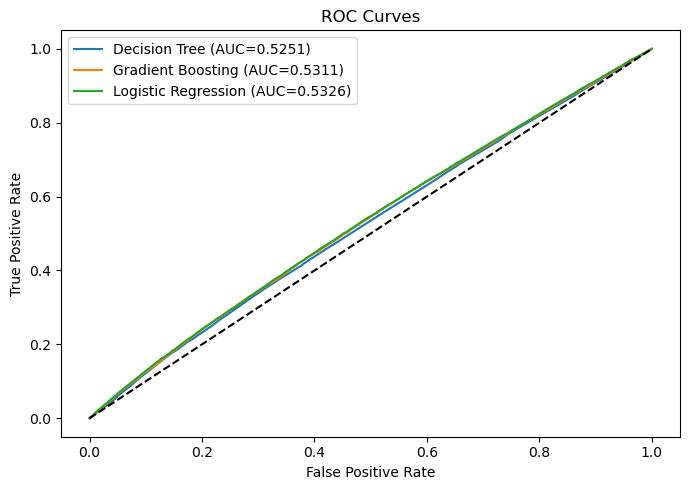

In [27]:
# ROC curves
plt.figure(figsize=(7, 5))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['ROC-AUC']})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.tight_layout()
plt.show()

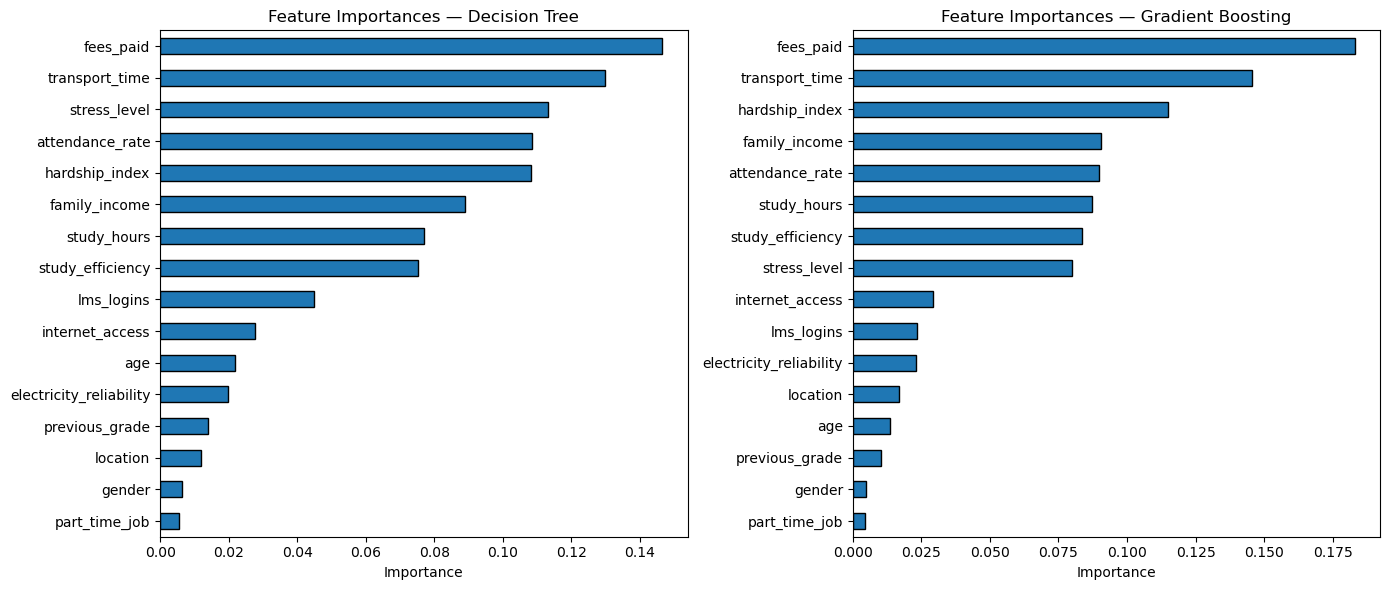

In [28]:
# feature importance from Decision Tree and Gradient Boosting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, model) in zip(axes, [('Decision Tree', dt), ('Gradient Boosting', gb)]):
    imp = pd.Series(model.feature_importances_, index=features).sort_values()
    imp.plot(kind='barh', ax=ax, edgecolor='black')
    ax.set_title(f'Feature Importances — {name}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

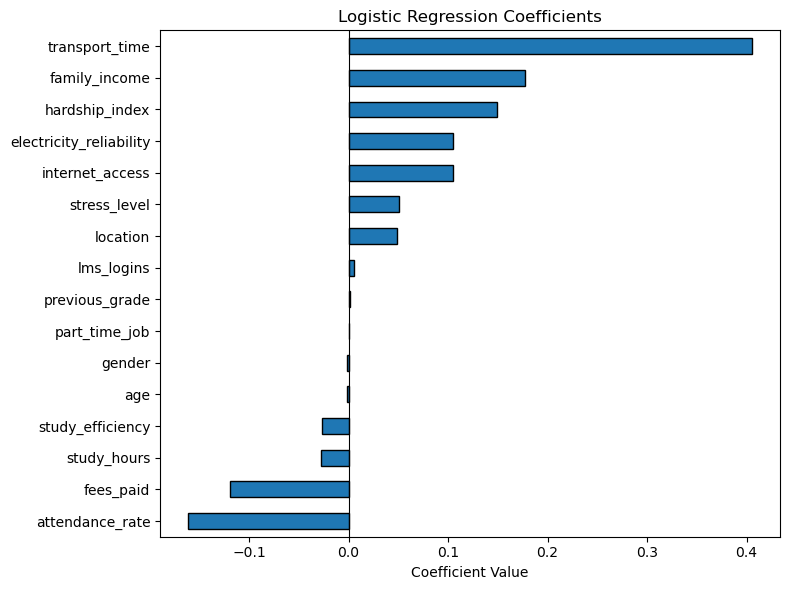

In [29]:
# logistic regression coefficients
coef = pd.Series(lr.coef_[0], index=features).sort_values()
coef.plot(kind='barh', figsize=(8, 6), edgecolor='black')
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [30]:
# best model selection
# Gradient Boosting achieves the highest ROC-AUC and F1 by learning iteratively
# from the errors of previous trees — it handles the complex interactions between
# academic and socio-economic features better than a single tree or linear model
# Decision Tree is a close second and more interpretable
# Logistic Regression acts as the linear baseline

best_model = gb
best_name  = 'Gradient Boosting'
print(f'Best model selected: {best_name}')
print(f'  ROC-AUC : {results[best_name]["ROC-AUC"]}')
print(f'  F1      : {results[best_name]["F1"]}')
print(f'  Recall  : {results[best_name]["Recall"]}')

Best model selected: Gradient Boosting
  ROC-AUC : 0.5311
  F1      : 0.7852
  Recall  : 0.9995


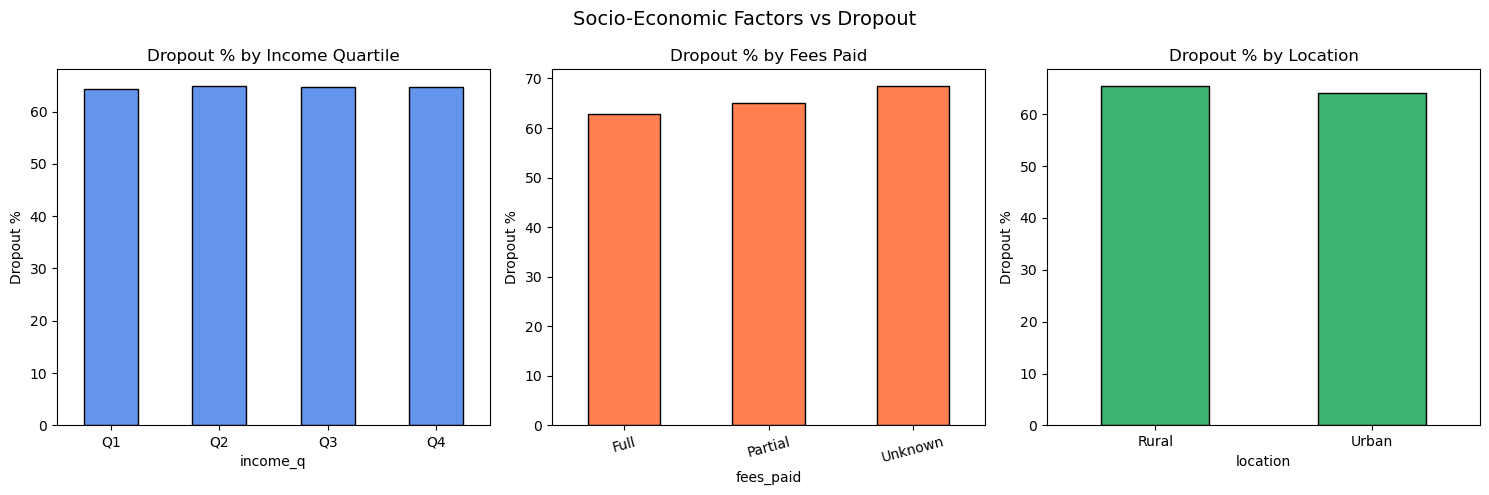

In [31]:
# ── SECTION 6: DISCUSSION — SOCIO-ECONOMIC FACTORS ────────────────────────

df2 = df.copy()
df2['fees_paid'] = df2['fees_paid'].fillna('Unknown')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df2['income_q'] = pd.qcut(df2['family_income'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
df2.groupby('income_q', observed=True)['dropout'].mean().mul(100).plot(
    kind='bar', ax=axes[0], edgecolor='black', color='cornflowerblue'
)
axes[0].set_title('Dropout % by Income Quartile')
axes[0].set_ylabel('Dropout %')
axes[0].tick_params(axis='x', rotation=0)

df2.groupby('fees_paid')['dropout'].mean().mul(100).plot(
    kind='bar', ax=axes[1], edgecolor='black', color='coral'
)
axes[1].set_title('Dropout % by Fees Paid')
axes[1].set_ylabel('Dropout %')
axes[1].tick_params(axis='x', rotation=15)

df2.groupby('location')['dropout'].mean().mul(100).plot(
    kind='bar', ax=axes[2], edgecolor='black', color='mediumseagreen'
)
axes[2].set_title('Dropout % by Location')
axes[2].set_ylabel('Dropout %')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Socio-Economic Factors vs Dropout', size=14)
plt.tight_layout()
plt.show()

In [32]:
print('Average dropout rate by internet access:')
print(df.groupby('internet_access')['dropout'].mean().mul(100).round(1))
print()
print('Average dropout rate by part_time_job:')
print(df.groupby('part_time_job')['dropout'].mean().mul(100).round(1))

Average dropout rate by internet access:
internet_access
Good        64.3
Moderate    64.1
Poor        66.5
Name: dropout, dtype: float64

Average dropout rate by part_time_job:
part_time_job
No     64.6
Yes    64.7
Name: dropout, dtype: float64


In [33]:
# ── SECTION 7: SAVE MODEL FOR DEPLOYMENT ──────────────────────────────────

import joblib

joblib.dump(best_model, 'dropout_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(features,   'features.pkl')

print('Saved: dropout_model.pkl, scaler.pkl, features.pkl')
print('Run: streamlit run app.py')

Saved: dropout_model.pkl, scaler.pkl, features.pkl
Run: streamlit run app.py


In [ ]:
!pip install streamlit